In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [5]:
DATA_DIR = '../data/human-and-non-human/training_set'
IMG_SIZE = 96
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale" # تبدیل مستقیم به سیاه‌سفید
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 8017 files belonging to 2 classes.
Using 6414 files for training.
Found 8017 files belonging to 2 classes.
Using 1603 files for validation.


In [6]:
def normalize_pixels(image, label):
    return image/255.0, label

train_dataset = train_dataset.map(normalize_pixels).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(normalize_pixels).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("data loaded and normalized successfuly.")

data loaded and normalized successfuly.


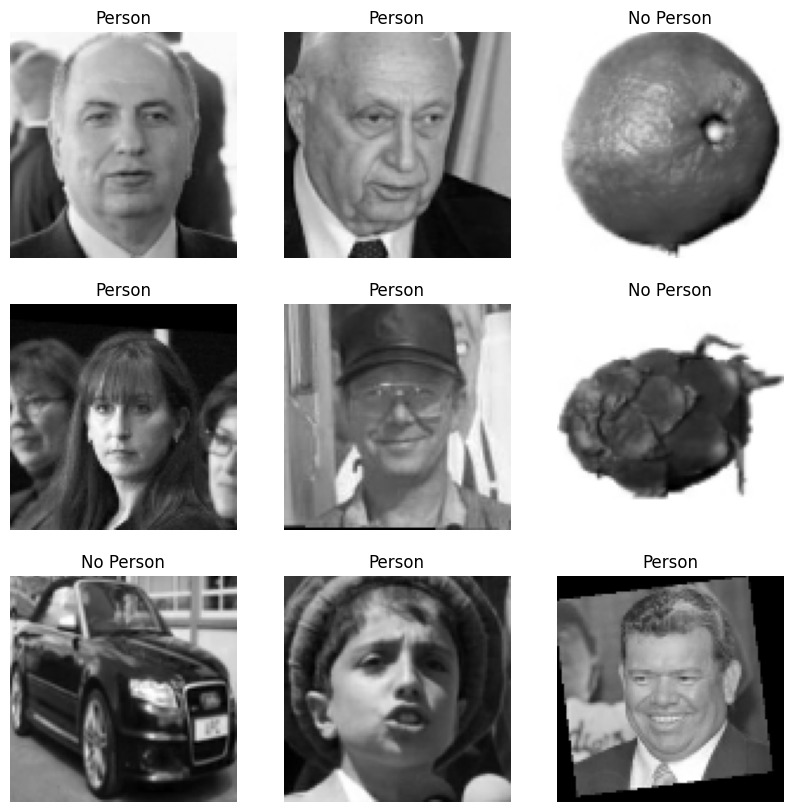

In [9]:
class_names = ['Person', 'No Person']

plt.figure(figsize=(10, 10))

for images, labels in train_dataset:
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis("off")
        
plt.show()
        